# Comparing the fit results for NGC~1097 with the those presented in Bittner+20

In [5]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

## Reading bittner+20 data products

In [6]:
bittner_ngc1097_path = '../../data/misc_data/all_pops_mass/NGC1097_pops_mass.fits'

with fits.open(bittner_ngc1097_path) as hdul:
    hdul.info()
    metal_bittner = hdul['metal'].data
    age_bittner = hdul['age'].data

Filename: ../../data/misc_data/all_pops_mass/NGC1097_pops_mass.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  AGE           1 ImageHDU         8   (319, 319)   float64   
  2  METAL         1 ImageHDU         8   (319, 319)   float64   
  3  ALPHA         1 ImageHDU         8   (319, 319)   float64   


## Reading this work data products

In [7]:
# Metallicity

ngc1097_metal_path_miles = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/'
                            'ppxf/mean_mh_light.fits')

with fits.open(ngc1097_metal_path_miles) as hdul:
    print('\nmiles metallicity')
    hdul.info()
    metal_miles = hdul[0].data
    
    
ngc1097_metal_path_xsl = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/XSLAgeMh/'
                            'ppxf/mean_mh_light.fits')

with fits.open(ngc1097_metal_path_xsl) as hdul:
    print('\nXSL metallicity')
    hdul.info()
    metal_xsl = hdul[0].data
    
# Age

ngc1097_age_path_miles = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/'
                          'ppxf/mean_log10_age_light.fits')

with fits.open(ngc1097_age_path_miles) as hdul:
    print('\nmiles age')
    hdul.info()
    age_miles = hdul[0].data
    
    
ngc1097_age_path_xsl = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/XSLAgeMh/'
                        'ppxf/mean_log10_age_light.fits')

with fits.open(ngc1097_age_path_xsl) as hdul:
    print('\nXSL age')
    hdul.info()
    age_xsl = hdul[0].data
    
# Av

ngc1097_av_path_miles = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/'
                          'ppxf/a_v.fits')

with fits.open(ngc1097_av_path_miles) as hdul:
    print('\nmiles age')
    hdul.info()
    av_miles = hdul[0].data
    
    
ngc1097_av_path_xsl = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/XSLAgeMh/'
                        'ppxf/a_v.fits')

with fits.open(ngc1097_av_path_xsl) as hdul:
    print('\nXSL age')
    hdul.info()
    av_xsl = hdul[0].data



miles metallicity
Filename: ../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/ppxf/mean_mh_light.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (326, 320)   float64   

XSL metallicity
Filename: ../../data_products/NGC1097_DATACUBE_FINAL_clean/XSLAgeMh/ppxf/mean_mh_light.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (326, 320)   float64   

miles age
Filename: ../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMh/ppxf/mean_log10_age_light.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (326, 320)   float64   

XSL age
Filename: ../../data_products/NGC1097_DATACUBE_FINAL_clean/XSLAgeMh/ppxf/mean_log10_age_light.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (326, 320)   float64   

miles age
Filename: ../../data_products/NGC10

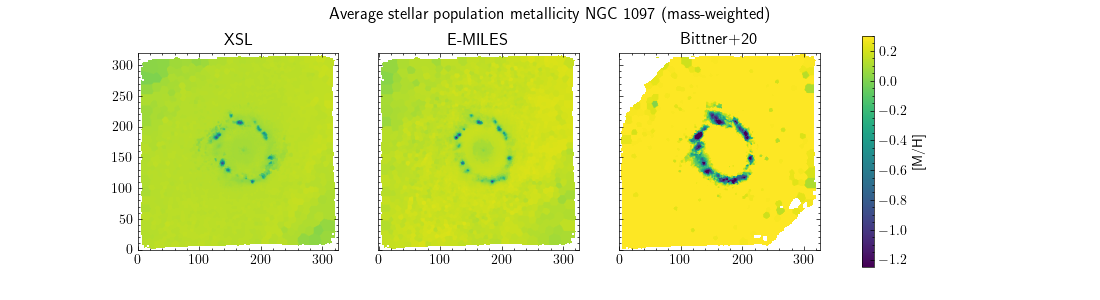

In [8]:
%matplotlib widget

# print(metal_bittner.shape)
# print(metal_miles.shape)

# There is a difference between the shapes, adding some columns and rows with NaN to try to fix it
aux_metal = np.full_like(metal_miles, fill_value=np.nan)
aux_metal[:-1, 2:-5] = metal_bittner

with plt.style.context('science'):
    fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(11,3))
  
    vmin = -1.25
    vmax = 0.3
    
    cmap = 'viridis'

    im0 = ax[0].imshow(metal_xsl, origin='lower', vmin=vmin, vmax=vmax, cmap=cmap)
    ax[0].set_title('XSL')

    ax[1].imshow(metal_miles, origin='lower', vmin=vmin, vmax=vmax, cmap=cmap)
    ax[1].set_title('E-MILES')
   
    ax[2].imshow(aux_metal, origin='lower', vmin=-0.8, vmax=0.2, cmap=cmap)
    ax[2].set_title('Bittner+20')
    
    cbar = fig.colorbar(im0, ax=ax[:])
    cbar.set_label(r'[M/H]')
    
    fig.suptitle(r'Average stellar population metallicity NGC~1097 (mass-weighted)')
    

## Parameter range used:

| Library | Age range [Gyr]| Metallicity [dex] |
| ------: | :------------: | :---------------: |
| XSL     | 0.05 - 15.85   | -1.80 - 0.20      |
| E-MILES | 0.06 - 12.58   | -1.71 - 0.22      |
| Bittner+2020 | 0.03 - 14.00   | -2.27 - 0.40      |


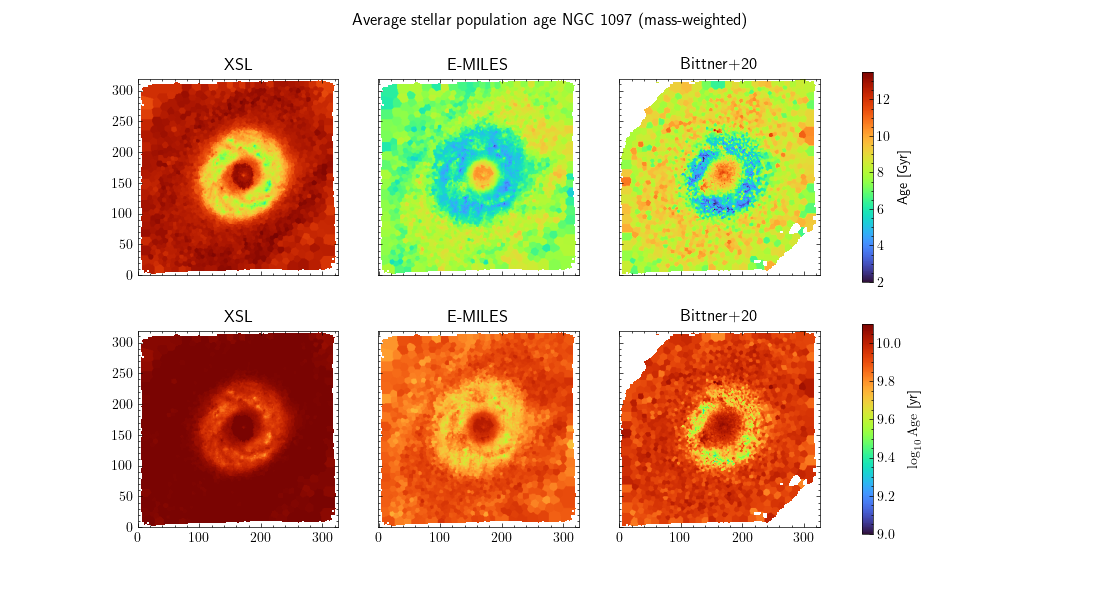

In [9]:
# There is a difference between the shapes, adding some columns and rows with NaN to try to fix it
aux_age = np.full_like(age_miles, fill_value=np.nan)
aux_age[:-1, 2:-5] = age_bittner

with plt.style.context('science'):
    fig, ax = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(11,6))

    vmin = 2
    vmax = 13.5
    cmap = 'turbo'

    im0 = ax[0, 0].imshow(10**(age_xsl-9), origin='lower', vmin=vmin, vmax=vmax, cmap=cmap)
    ax[0, 0].set_title('XSL')

    ax[0, 1].imshow(10**(age_miles-9), origin='lower', vmin=vmin, vmax=vmax, cmap=cmap)
    ax[0, 1].set_title('E-MILES')
   
    ax[0, 2].imshow(aux_age, origin='lower', vmin=vmin, vmax=vmax, cmap=cmap)
    ax[0, 2].set_title('Bittner+20')
    
    cbar = fig.colorbar(im0, ax=ax[0, :])
    cbar.set_label(r'Age [Gyr]')
              
    vmin = 9
    vmax = 10.1
    cmap = 'turbo'
    
    im0 = ax[1, 0].imshow(age_xsl, origin='lower', vmin=vmin, vmax=vmax, cmap=cmap)
    ax[1, 0].set_title('XSL')

    ax[1, 1].imshow(age_miles, origin='lower', vmin=vmin, vmax=vmax, cmap=cmap)
    ax[1, 1].set_title('E-MILES')
   
    ax[1, 2].imshow(np.log10(aux_age*1e9), origin='lower', vmin=vmin, vmax=vmax, cmap=cmap)
    ax[1, 2].set_title('Bittner+20')
    
    cbar = fig.colorbar(im0, ax=ax[1, :])
    cbar.set_label(r'$\log_{10}{\rm{Age}}$ [yr]')
    
    fig.suptitle(r'Average stellar population age NGC~1097 (mass-weighted)')

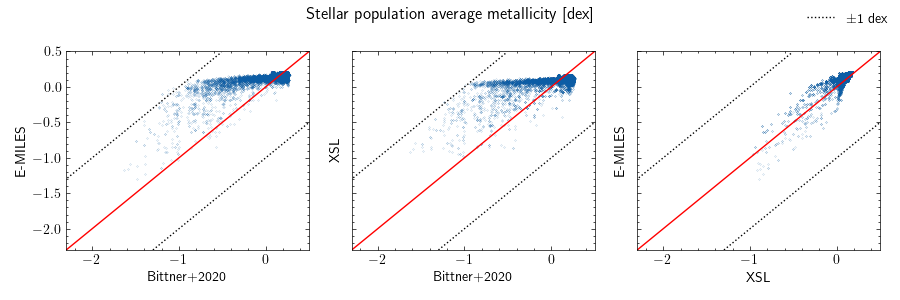

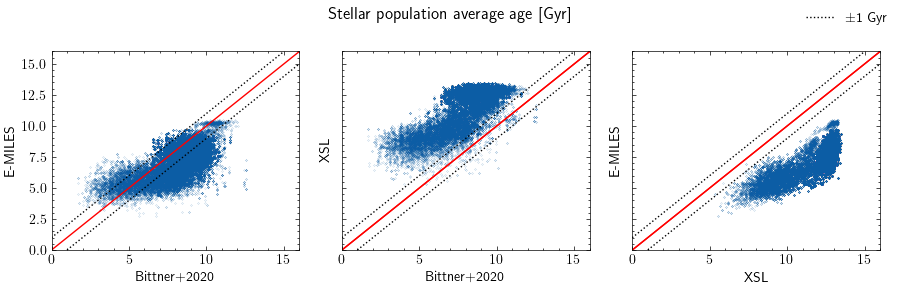

In [10]:
with plt.style.context('science'):
    fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(9,3), tight_layout=True)

    # metal
    ax[0].scatter(aux_metal, metal_miles, s=0.01)
    ax[0].plot(np.arange(-2.3,0.5, 1e-2), np.arange(-2.3,0.5, 1e-2), color='red')
    ax[0].plot(np.arange(-2.3+1, 0.5+1, 1e-2), np.arange(-2.3,0.5, 1e-2), color='black', ls='dotted', label=r'$\pm$1~dex')
    ax[0].plot(np.arange(-2.3-1, 0.5-1, 1e-2), np.arange(-2.3,0.5, 1e-2), color='black', ls='dotted')
    ax[0].set_xlim(-2.3, 0.5)
    ax[0].set_ylim(-2.3, 0.5)
    ax[0].set_xlabel('Bittner+2020')
    ax[0].set_ylabel('E-MILES')

    ax[1].scatter(aux_metal, metal_xsl, s=0.01)
    ax[1].plot(np.arange(-2.3,0.5, 1e-2), np.arange(-2.3,0.5, 1e-2), color='red')
    ax[1].plot(np.arange(-2.3+1, 0.5+1, 1e-2), np.arange(-2.3,0.5, 1e-2), color='black', ls='dotted')
    ax[1].plot(np.arange(-2.3-1, 0.5-1, 1e-2), np.arange(-2.3,0.5, 1e-2), color='black', ls='dotted')
    ax[1].set_xlim(-2.3, 0.5)
    ax[1].set_ylim(-2.3, 0.5)
    ax[1].set_xlabel('Bittner+2020')
    ax[1].set_ylabel('XSL')
    
    ax[2].scatter(metal_xsl, metal_miles, s=0.01)
    ax[2].plot(np.arange(-2.3,0.5, 1e-2), np.arange(-2.3,0.5, 1e-2), color='red')
    ax[2].plot(np.arange(-2.3+1, 0.5+1, 1e-2), np.arange(-2.3,0.5, 1e-2), color='black', ls='dotted')
    ax[2].plot(np.arange(-2.3-1, 0.5-1, 1e-2), np.arange(-2.3,0.5, 1e-2), color='black', ls='dotted')
    ax[2].set_xlim(-2.3, 0.5)
    ax[2].set_ylim(-2.3, 0.5)
    ax[2].set_xlabel('XSL')
    ax[2].set_ylabel('E-MILES')
     
    fig.suptitle('Stellar population average metallicity [dex]')
    fig.legend()

with plt.style.context('science'):
    fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(9,3), tight_layout=True)

    ax[0].scatter(aux_age, 10**(age_miles-9), s=0.01)
    ax[0].plot(np.arange(0, 16, 1e-2), np.arange(0, 16, 1e-2), color='red')
    ax[0].plot(np.arange(0+1, 16+1, 1e-2), np.arange(0, 16, 1e-2), color='black', ls='dotted', label=r'$\pm$1~Gyr')
    ax[0].plot(np.arange(0-1, 16-1, 1e-2), np.arange(0, 16, 1e-2), color='black', ls='dotted')
    ax[0].set_xlim(0, 16)
    ax[0].set_ylim(0, 16)
    ax[0].set_xlabel('Bittner+2020')
    ax[0].set_ylabel('E-MILES')

    ax[1].scatter(aux_age, 10**(age_xsl-9), s=0.01)
    ax[1].plot(np.arange(0, 16, 1e-2), np.arange(0, 16, 1e-2), color='red')
    ax[1].plot(np.arange(0, 16, 1e-2), np.arange(0, 16, 1e-2), color='red')
    ax[1].plot(np.arange(0+1, 16+1, 1e-2), np.arange(0, 16, 1e-2), color='black', ls='dotted')
    ax[1].plot(np.arange(0-1, 16-1, 1e-2), np.arange(0, 16, 1e-2), color='black', ls='dotted')
    ax[1].set_xlim(0, 16)
    ax[1].set_ylim(0, 16)
    ax[1].set_xlabel('Bittner+2020')
    ax[1].set_ylabel('XSL')
    
    ax[2].scatter(10**(age_xsl-9), 10**(age_miles-9), s=0.01)
    ax[2].plot(np.arange(0, 16, 1e-2), np.arange(0, 16, 1e-2), color='red')
    ax[2].plot(np.arange(0, 16, 1e-2), np.arange(0, 16, 1e-2), color='red')
    ax[2].plot(np.arange(0+1, 16+1, 1e-2), np.arange(0, 16, 1e-2), color='black', ls='dotted')
    ax[2].plot(np.arange(0-1, 16-1, 1e-2), np.arange(0, 16, 1e-2), color='black', ls='dotted')
    ax[2].set_xlim(0, 16)
    ax[0].set_ylim(0, 16)
    ax[2].set_xlabel('XSL')
    ax[2].set_ylabel('E-MILES')

    fig.suptitle('Stellar population average age [Gyr]')
    fig.legend()


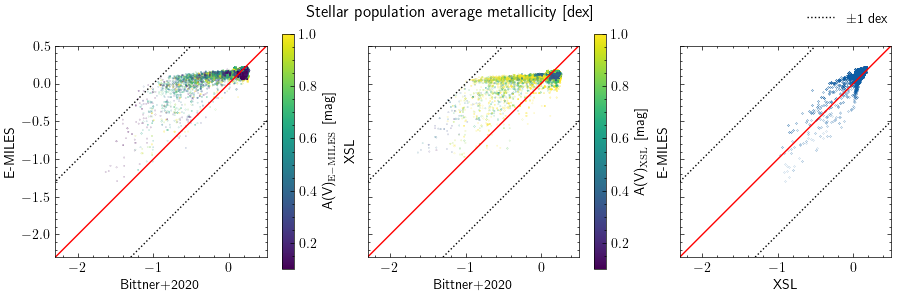

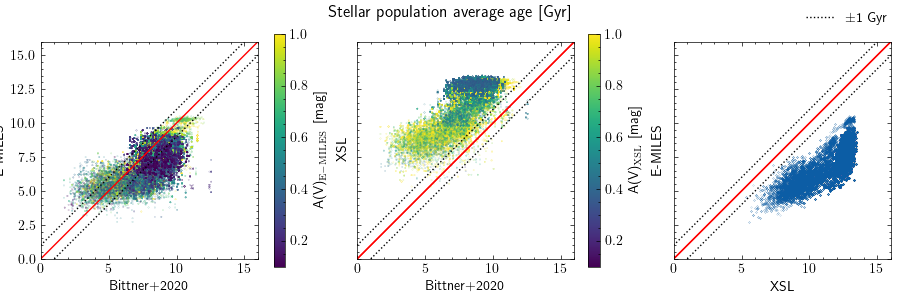

In [11]:
with plt.style.context('science'):
    fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(9,3), constrained_layout=True, subplot_kw=dict(box_aspect=1))
    
    cmap = 'viridis'
    vmin = 0.1
    vmax = 1
    
    # metal
    im0 = ax[0].scatter(aux_metal, metal_miles, s=0.01, c=av_miles, cmap=cmap, vmin=vmin, vmax=vmax)
    ax[0].plot(np.arange(-2.3,0.5, 1e-2), np.arange(-2.3,0.5, 1e-2), color='red')
    ax[0].plot(np.arange(-2.3+1, 0.5+1, 1e-2), np.arange(-2.3,0.5, 1e-2), color='black', ls='dotted', label=r'$\pm$1~dex')
    ax[0].plot(np.arange(-2.3-1, 0.5-1, 1e-2), np.arange(-2.3,0.5, 1e-2), color='black', ls='dotted')
    ax[0].set_xlim(-2.3, 0.5)
    ax[0].set_ylim(-2.3, 0.5)
    ax[0].set_xlabel('Bittner+2020')
    ax[0].set_ylabel('E-MILES')
    cbar0 = fig.colorbar(im0, ax=ax[0])
    cbar0.set_label(r'A(V)$_{\rm{E-MILES}}$ [mag]')

    im1 = ax[1].scatter(aux_metal, metal_xsl, s=0.01, c=av_xsl, cmap=cmap, vmin=vmin, vmax=vmax)
    ax[1].plot(np.arange(-2.3,0.5, 1e-2), np.arange(-2.3,0.5, 1e-2), color='red')
    ax[1].plot(np.arange(-2.3+1, 0.5+1, 1e-2), np.arange(-2.3,0.5, 1e-2), color='black', ls='dotted')
    ax[1].plot(np.arange(-2.3-1, 0.5-1, 1e-2), np.arange(-2.3,0.5, 1e-2), color='black', ls='dotted')
    ax[1].set_xlim(-2.3, 0.5)
    ax[1].set_ylim(-2.3, 0.5)
    ax[1].set_xlabel('Bittner+2020')
    ax[1].set_ylabel('XSL')
    cbar1 = fig.colorbar(im1, ax=ax[1])
    cbar1.set_label(r'A(V)$_{\rm{XSL}}$ [mag]')
    
    ax[2].scatter(metal_xsl, metal_miles, s=0.01)
    ax[2].plot(np.arange(-2.3,0.5, 1e-2), np.arange(-2.3,0.5, 1e-2), color='red')
    ax[2].plot(np.arange(-2.3+1, 0.5+1, 1e-2), np.arange(-2.3,0.5, 1e-2), color='black', ls='dotted')
    ax[2].plot(np.arange(-2.3-1, 0.5-1, 1e-2), np.arange(-2.3,0.5, 1e-2), color='black', ls='dotted')
    ax[2].set_xlim(-2.3, 0.5)
    ax[2].set_ylim(-2.3, 0.5)
    ax[2].set_xlabel('XSL')
    ax[2].set_ylabel('E-MILES')
    
    fig.suptitle('Stellar population average metallicity [dex]')
    fig.legend()

with plt.style.context('science'):
    fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(9,3), constrained_layout=True, subplot_kw=dict(box_aspect=1))

    ax[0].scatter(aux_age, 10**(age_miles-9), s=0.01, c=av_miles, cmap=cmap, vmin=vmin, vmax=vmax)
    ax[0].plot(np.arange(0, 16, 1e-2), np.arange(0, 16, 1e-2), color='red')
    ax[0].plot(np.arange(0+1, 16+1, 1e-2), np.arange(0, 16, 1e-2), color='black', ls='dotted', label=r'$\pm$1~Gyr')
    ax[0].plot(np.arange(0-1, 16-1, 1e-2), np.arange(0, 16, 1e-2), color='black', ls='dotted')
    ax[0].set_xlim(0, 16)
    ax[0].set_ylim(0, 16)
    ax[0].set_xlabel('Bittner+2020')
    ax[0].set_ylabel('E-MILES')
    cbar0 = fig.colorbar(im0, ax=ax[0])
    cbar0.set_label(r'A(V)$_{\rm{E-MILES}}$ [mag]')

    ax[1].scatter(aux_age, 10**(age_xsl-9), s=0.01, c=av_xsl, cmap=cmap, vmin=vmin, vmax=vmax)
    ax[1].plot(np.arange(0, 16, 1e-2), np.arange(0, 16, 1e-2), color='red')
    ax[1].plot(np.arange(0, 16, 1e-2), np.arange(0, 16, 1e-2), color='red')
    ax[1].plot(np.arange(0+1, 16+1, 1e-2), np.arange(0, 16, 1e-2), color='black', ls='dotted')
    ax[1].plot(np.arange(0-1, 16-1, 1e-2), np.arange(0, 16, 1e-2), color='black', ls='dotted')
    ax[1].set_xlim(0, 16)
    ax[1].set_ylim(0, 16)
    ax[1].set_xlabel('Bittner+2020')
    ax[1].set_ylabel('XSL')
    cbar1 = fig.colorbar(im1, ax=ax[1])
    cbar1.set_label(r'A(V)$_{\rm{XSL}}$ [mag]')
    
    ax[2].scatter(10**(age_xsl-9), 10**(age_miles-9), s=0.01)
    ax[2].plot(np.arange(0, 16, 1e-2), np.arange(0, 16, 1e-2), color='red')
    ax[2].plot(np.arange(0, 16, 1e-2), np.arange(0, 16, 1e-2), color='red')
    ax[2].plot(np.arange(0+1, 16+1, 1e-2), np.arange(0, 16, 1e-2), color='black', ls='dotted')
    ax[2].plot(np.arange(0-1, 16-1, 1e-2), np.arange(0, 16, 1e-2), color='black', ls='dotted')
    ax[2].set_xlim(0, 16)
    ax[0].set_ylim(0, 16)
    ax[2].set_xlabel('XSL')
    ax[2].set_ylabel('E-MILES')

    fig.suptitle('Stellar population average age [Gyr]')
    fig.legend()
